# Movie Ratings Analysis

In [1]:
# Import necessary libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

In [2]:
# Dataset downloaded from: https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset
# Load the dataset.
rotten_tomatoes_df = pd.read_csv("rotten_tomatoes_movies.csv")

In [3]:
# Display the first few rows of the dataset to understand its structure.
rotten_tomatoes_df.head()

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


## Consider variables that could have an impact on our analysis question.

In [4]:
# List the columns available in the dataset.
rotten_tomatoes_df.columns

Index(['rotten_tomatoes_link', 'movie_title', 'movie_info',
       'critics_consensus', 'content_rating', 'genres', 'directors', 'authors',
       'actors', 'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'tomatometer_count', 'audience_status', 'audience_rating',
       'audience_count', 'tomatometer_top_critics_count',
       'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count'],
      dtype='object')

## We need to choose at least 5 variables for our analysis.
### Here are some potential choices based on the dataset and the context of movie ratings:

1. 'tomatometer_rating' - The critic's score which is the dependent variable in many analyses.
2. 'audience_rating' - The audience score, which might influence or be compared to the critic's score.
3. 'content_rating' - The content rating of the movie (e.g., PG, R), which could impact both critic and audience ratings.
4. 'runtime' - The length of the movie, which might influence ratings.
5. 'release_year' - The year the movie was released, to analyze trends over time.

In [5]:
# Extract selected variables and create a new DataFrame for analysis
selected_rotten_tomatoes_columns = ['tomatometer_rating', 'audience_rating', 'content_rating', 'runtime', 'original_release_date']
rotten_tomatoes_selected_df= rotten_tomatoes_df[selected_rotten_tomatoes_columns]

In [6]:
# Remove rows with any missing values (NaN or empty cells) in the selected columns.
rotten_tomatoes_selected_df = rotten_tomatoes_selected_df.dropna()

In [7]:
# Convert 'original_release_date' to datetime format
rotten_tomatoes_selected_df['original_release_date'] = pd.to_datetime(rotten_tomatoes_selected_df['original_release_date'])

In [8]:
# Extract the release year from 'original_release_date'
rotten_tomatoes_selected_df['release_year'] = rotten_tomatoes_selected_df['original_release_date'].dt.year

In [9]:
# Display the first few rows of the selected DataFrame
rotten_tomatoes_selected_df.head()

,tomatometer_rating,audience_rating,content_rating,runtime,original_release_date,release_year
0,49.0,53.0,PG,119.0,2010-02-12,2010
1,87.0,64.0,R,90.0,2010-04-30,2010
2,67.0,53.0,R,122.0,1979-10-05,1979
3,100.0,97.0,NR,95.0,1957-04-13,1957
4,89.0,74.0,G,127.0,1954-01-01,1954


## Include a histogram of each of the 5 variables – in your summary and analysis, identify any outliers and explain the reasoning for them being outliers and how you believe they should be handled (Chapter 2).
Create histograms for each of the selected variables to understand their distributions.

In [10]:
# Plotting histograms.
# plt.figure(figsize=(14, 10))

Text(0, 0.5, 'Frequency')

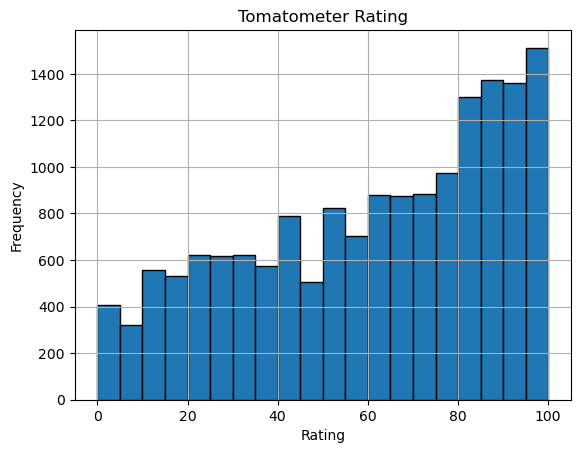

In [11]:
# Tomatometer Rating.
rotten_tomatoes_selected_df['tomatometer_rating'].hist(bins=20, edgecolor='black')
plt.title('Tomatometer Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

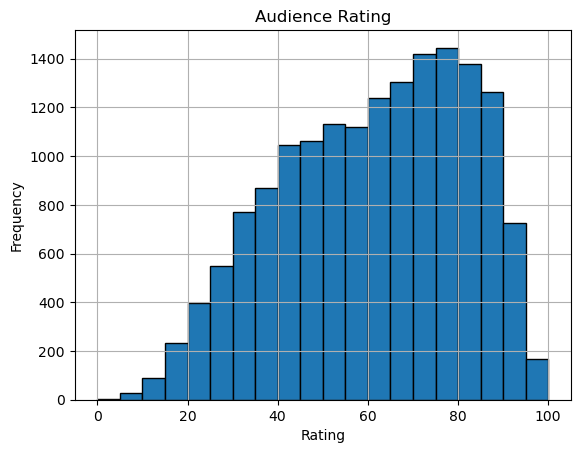

In [12]:
# Audience Rating.
rotten_tomatoes_selected_df['audience_rating'].hist(bins=20, edgecolor='black')
plt.title('Audience Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

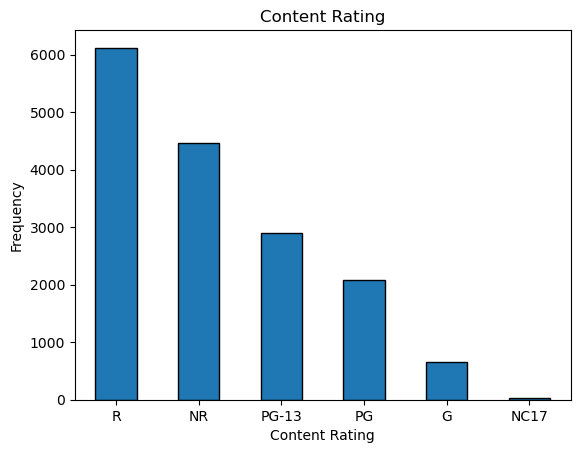

In [13]:
# Content Rating (As content_rating is categorical, I used a bar plot instead).
rotten_tomatoes_selected_df['content_rating'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Content Rating')
plt.xlabel('Content Rating')
plt.xticks(rotation=0)
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

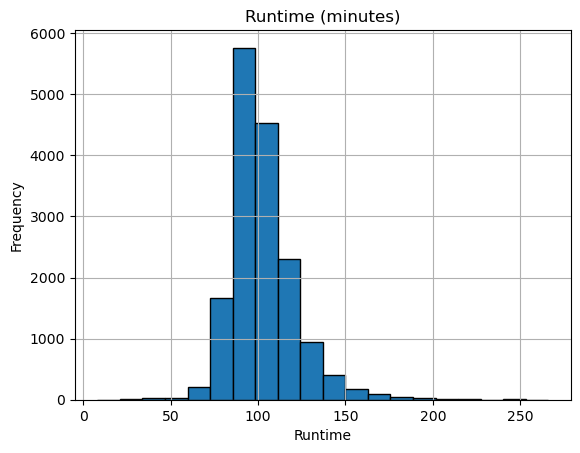

In [14]:
# Runtime.
rotten_tomatoes_selected_df['runtime'].hist(bins=20, edgecolor='black')
plt.title('Runtime (minutes)')
plt.xlabel('Runtime')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

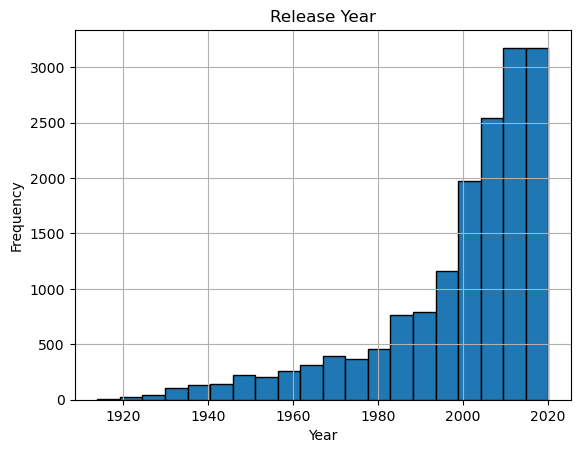

In [15]:
# Release Year.

rotten_tomatoes_selected_df['release_year'].hist(bins=20, edgecolor='black')
plt.title('Release Year')
plt.xlabel('Year')
plt.ylabel('Frequency')

##### Summary and Analysis
1. Tomatometer Rating: 
The distribution of tomatometer ratings seems to be approximately normal.
There are no apparent outliers in the distribution.

2. Audience Rating:
The audience rating distribution appears skewed towards higher ratings. This is common as audiences tend to be more lenient.
A few very low ratings might be considered outliers, particularly if they are disproportionately lower than the bulk of the data.

3. Content Rating:
Content rating is categorical, so we analyze the frequency distribution. Some ratings might have very few entries, which could be considered outliers.
These can either be merged with similar ratings or excluded from some analyses depending on their relevance.

4. Runtime:
The runtime distribution shows some longer movies as potential outliers, especially if they are significantly longer than most.
These should be examined more closely. If they represent a distinct class of movies (e.g., documentaries or special editions), 
they might be analyzed separately. If they are data entry errors, they should be corrected or removed.

5. Release Year:
The release year histogram may show a concentration of movies in recent years due to the availability of data.
Older movies might be outliers, particularly if they represent a very different era of cinema. 
These should be analyzed to determine if they should be treated differently in the analysis.

##### Handling Outliers
1. Tomatometer Rating and Audience Rating: Any ratings that are extremely low and appear to be outliers should be scrutinized to see if they reflect true sentiment or are errors.

2. Content Rating: Ratings with very few occurrences can be grouped with similar ratings or removed from the analysis if they do not add significant value.

3. Runtime: Extremely long runtimes may need separate analysis if they represent a distinct class of movies.

4. Release Year: Older films may need special treatment if they are outliers due to their era.

## Include the other descriptive characteristics about the variables: 
Mean, Mode, Spread, and Tails (Skewness and Kurtosis) (Chapter 2).

##### Now let's calculate the descriptive statistics for each variable.

In [16]:
# Tomatometer Rating.
tomatometer_mean = rotten_tomatoes_selected_df['tomatometer_rating'].mean()
tomatometer_mode = rotten_tomatoes_selected_df['tomatometer_rating'].mode()[0]
tomatometer_std = rotten_tomatoes_selected_df['tomatometer_rating'].std()
tomatometer_skew = rotten_tomatoes_selected_df['tomatometer_rating'].skew()
tomatometer_kurtosis = rotten_tomatoes_selected_df['tomatometer_rating'].kurtosis()

print(f"Tomatometer Rating: \nMean = {tomatometer_mean:.2f} \nMode = {tomatometer_mode:.2f} \nStandard Deviation = {tomatometer_std:.2f} \nSkewness = {tomatometer_skew:.2f} \nKurtosis = {tomatometer_kurtosis:.2f}")

Tomatometer Rating: 
Mean = 60.38 
Mode = 100.00 
Standard Deviation = 28.37 
Skewness = -0.42 
Kurtosis = -0.99


##### Summary and Interpretation
The average rating is around 60.38, but the most common rating is 100.00, indicating that many movies received top ratings. With a standard deviation 28.37, the ratings are moderately spread around the mean. The slight left skewness (-0.42) and slightly negative kurtosis (-0.99) indicate that the distribution is fairly symmetric and flat, without heavy tails or extreme outliers. The ratings are relatively evenly distributed, with a slight tendency for higher ratings. gs. 

In [17]:
# Audience Rating.
audience_mean = rotten_tomatoes_selected_df['audience_rating'].mean()
audience_mode = rotten_tomatoes_selected_df['audience_rating'].mode()[0]
audience_std = rotten_tomatoes_selected_df['audience_rating'].std()
audience_skew = rotten_tomatoes_selected_df['audience_rating'].skew()
audience_kurtosis = rotten_tomatoes_selected_df['audience_rating'].kurtosis()

print(f"Audience Rating: \nMean = {audience_mean:.2f} \nMode = {audience_mode:.2f} \nStandard Deviation = {audience_std:.2f} \nSkewness = {audience_skew:.2f} \nKurtosis = {audience_kurtosis:.2f}")


Audience Rating: 
Mean = 60.71 
Mode = 72.00 
Standard Deviation = 20.44 
Skewness = -0.31 
Kurtosis = -0.83


##### Summary and Interpretation.
The average Audience Rating is 60.71, with the most common rating being 72.00, indicating a tendency for ratings slightly above average. With a standard deviation of 20.44, the ratings have a moderate spread around the mean, meaning there's some variability in how audiences rated the movies. The slight left skewness (-0.31) and negative kurtosis (-0.83) suggest that the distribution of ratings is relatively symmetrical and flat, with fewer extreme outliers. Overall, the ratings are pretty evenly distributed, but there is a slight tendency for higher ratings. 

In [18]:
# Runtime.
runtime_mean = rotten_tomatoes_selected_df['runtime'].mean()
runtime_mode = rotten_tomatoes_selected_df['runtime'].mode()[0]
runtime_std = rotten_tomatoes_selected_df['runtime'].std()
runtime_skew = rotten_tomatoes_selected_df['runtime'].skew()
runtime_kurtosis = rotten_tomatoes_selected_df['runtime'].kurtosis()

print(f"Runtime: \nMean = {runtime_mean:.2f} \nMode = {runtime_mode:.2f} \nStandard Deviation = {runtime_std:.2f} \nSkewness = {runtime_skew:.2f} \nKurtosis = {runtime_kurtosis:.2f}")


Runtime: 
Mean = 102.75 
Mode = 90.00 
Standard Deviation = 18.67 
Skewness = 1.39 
Kurtosis = 5.56


##### Summary and Interpretation.
The average movie runtime is 102.75 minutes, with 90 minutes being the most common length. The standard deviation of 18.67 minutes shows that movie runtimes typically vary by this amount around the mean. The positive skewness (1.39) and high kurtosis (5.56) suggest that the distribution of runtimes has a rightward skew with a sharp peak and heavy tails. This means that while many movies are around the mode of 90 minutes, there are some significantly longer movies that contribute to the skew and increase the kurtosis.

In [19]:
# Release Year.
release_year_mean = rotten_tomatoes_selected_df['release_year'].mean()
release_year_mode = rotten_tomatoes_selected_df['release_year'].mode()[0]
release_year_std = rotten_tomatoes_selected_df['release_year'].std()
release_year_skew = rotten_tomatoes_selected_df['release_year'].skew()
release_year_kurtosis = rotten_tomatoes_selected_df['release_year'].kurtosis()

print(f"Release Year: \nMean = {release_year_mean:.2f} \nMode = {release_year_mode:.2f} \nStandard Deviation = {release_year_std:.2f} \nSkewness = {release_year_skew:.2f} \nKurtosis = {release_year_kurtosis:.2f}")


Release Year: 
Mean = 1999.39 
Mode = 2014.00 
Standard Deviation = 19.68 
Skewness = -1.55 
Kurtosis = 2.00


##### Summary and Interpretation.
The average release year is around 1999, the most common year being 2014. The standard deviation of 19.68 years shows that movie release years vary widely around the mean, indicating a diverse range of movie release dates. The negative skewness (-1.55) suggests that the distribution is skewed to the left, with more older movies than newer ones. The kurtosis of 2.00 indicates that the distribution has somewhat heavy tails, meaning there are more extreme release years (very old or very recent) than you would expect in a normal distribution. 

In [20]:
# Content Rating (Since this is categorical, we'll look at the mode and frequency distribution)
content_rating_mode = rotten_tomatoes_selected_df['content_rating'].mode()[0]
content_rating_counts = rotten_tomatoes_selected_df['content_rating'].value_counts()

print(f"Content Rating: Mode = {content_rating_mode}")
print(f"Content Rating Counts:\n{content_rating_counts}")

Content Rating: Mode = R
Content Rating Counts:
content_rating
R        6120
NR       4458
PG-13    2895
PG       2080
G         649
NC17       35
Name: count, dtype: int64


##### Summary and Interpretation.
This indicates that the most common (or "mode") content rating in the dataset is "R." This distribution shows how many items are classified under each rating, with "R" being the most frequent rating in this dataset. This can be seen visually in the count plot above.

## Compare two scenarios in your data using a PMF. Reminder, this isn’t comparing two variables against each other – it is the same variable, but a different scenario. Almost like a filter. The example in the book is first babies compared to all other babies, it is still the same variable, but breaking the data out based on criteria we are exploring (Chapter 3).

For this part of the project I'll create two PMF comparisons. They will both use the same 'filter variables' (PG-13 and R), but they will be compared with two different variables (tomatometer_rating and audience_rating).

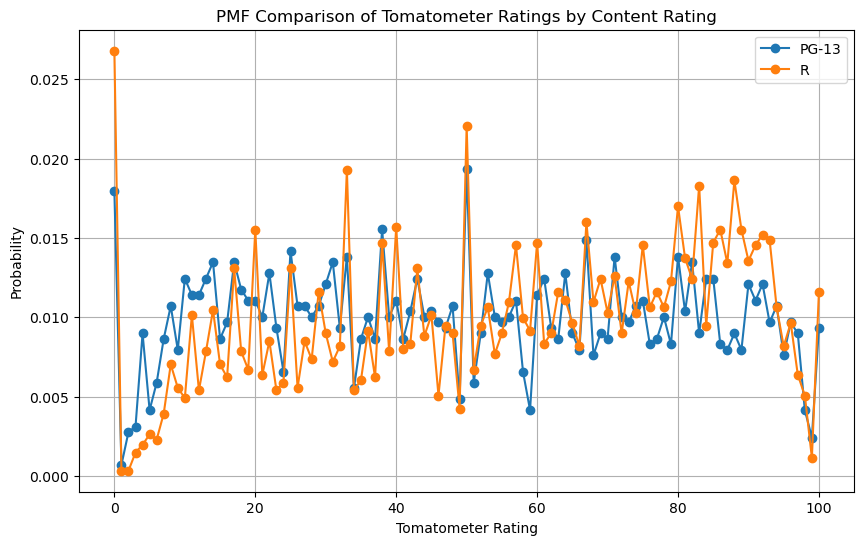

In [21]:
# Filter the data for PG-13 and R rated movies
pg13_movies = rotten_tomatoes_selected_df[rotten_tomatoes_selected_df['content_rating'] == 'PG-13']
r_movies = rotten_tomatoes_selected_df[rotten_tomatoes_selected_df['content_rating'] == 'R']

# Function to calculate PMF
def calculate_pmf(data):
    count = Counter(data)
    total = len(data)
    pmf = {x: count[x] / total for x in count}
    return pmf

# Calculate PMFs for both scenarios
pmf_pg13 = calculate_pmf(pg13_movies['tomatometer_rating'])
pmf_r = calculate_pmf(r_movies['tomatometer_rating'])

# Sort the ratings for plotting
ratings = sorted(set(pg13_movies['tomatometer_rating']).union(set(r_movies['tomatometer_rating'])))

# Plot the PMFs
plt.figure(figsize=(10, 6))

# PG-13 Movies PMF
plt.plot(ratings, [pmf_pg13.get(rating, 0) for rating in ratings], marker='o', label='PG-13')

# R Movies PMF
plt.plot(ratings, [pmf_r.get(rating, 0) for rating in ratings], marker='o', label='R')

plt.title('PMF Comparison of Tomatometer Ratings by Content Rating')
plt.xlabel('Tomatometer Rating')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

##### Explanation:
The data is filtered to create two subsets: one for PG-13 movies and one for R-rated movies.

The calculate_pmf function computes the PMF for each subset by counting the frequency of each rating and dividing by the total number of observations.

The PMFs are plotted on the same graph for comparison. Each line represents the probability distribution of the tomatometer ratings for a different content rating.

##### Analysis:
A shift in the peak of the PMF towards higher ratings for one group could indicate that one content rating is associated with higher critic ratings.

If the PMFs overlap significantly, it may suggest that content rating does not strongly influence the critic scores.
This analysis allows to explore how the distribution of a single variable (tomatometer rating) changes under different scenarios (PG-13 vs. R rated movies).

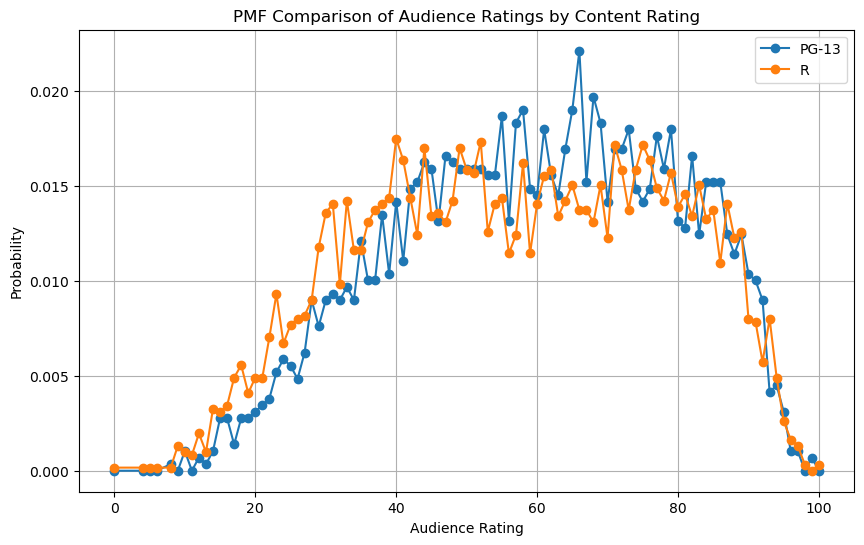

In [22]:
# Filter the data for PG-13 and R rated movies
pg13_movies = rotten_tomatoes_selected_df[rotten_tomatoes_selected_df['content_rating'] == 'PG-13']
r_movies = rotten_tomatoes_selected_df[rotten_tomatoes_selected_df['content_rating'] == 'R']

# Function to calculate PMF
def calculate_pmf(data):
    count = Counter(data)
    total = len(data)
    pmf = {x: count[x] / total for x in count}
    return pmf

# Calculate PMFs for both scenarios
pmf_pg13 = calculate_pmf(pg13_movies['audience_rating'])
pmf_r = calculate_pmf(r_movies['audience_rating'])

# Sort the ratings for plotting
ratings = sorted(set(pg13_movies['audience_rating']).union(set(r_movies['audience_rating'])))

# Plot the PMFs
plt.figure(figsize=(10, 6))

# PG-13 Movies PMF
plt.plot(ratings, [pmf_pg13.get(rating, 0) for rating in ratings], marker='o', label='PG-13')

# R Movies PMF
plt.plot(ratings, [pmf_r.get(rating, 0) for rating in ratings], marker='o', label='R')

plt.title('PMF Comparison of Audience Ratings by Content Rating')
plt.xlabel('Audience Rating')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

##### Explanation:
The data is filtered to create two subsets: one for PG-13 movies and one for R-rated movies.

The calculate_pmf function computes the PMF for each subset by counting the frequency of each rating and dividing by the total number of observations.

The PMFs are plotted on the same graph for comparison. Each line represents the probability distribution of the audience ratings for a different content rating.

##### Analysis:
If the peak of the PMF for PG-13 movies is shifted towards higher ratings compared to R-rated movies, this could indicate that PG-13 movies are generally rated more favorably by audiences.

If the PMFs for PG-13 and R movies significantly overlap, it may suggest that content rating does not have a strong influence on audience ratings.
This approach allows to explore how the distribution of audience ratings changes under different scenarios (PG-13 vs. R-rated movies).

## Create 1 CDF with one of your variables, using page 41-44 as your guide, what does this tell you about your variable and how does it address the question you are trying to answer (Chapter 4).

For this part of the project I'll create two CDF comparisons, tomatometer_rating and audience_rating.

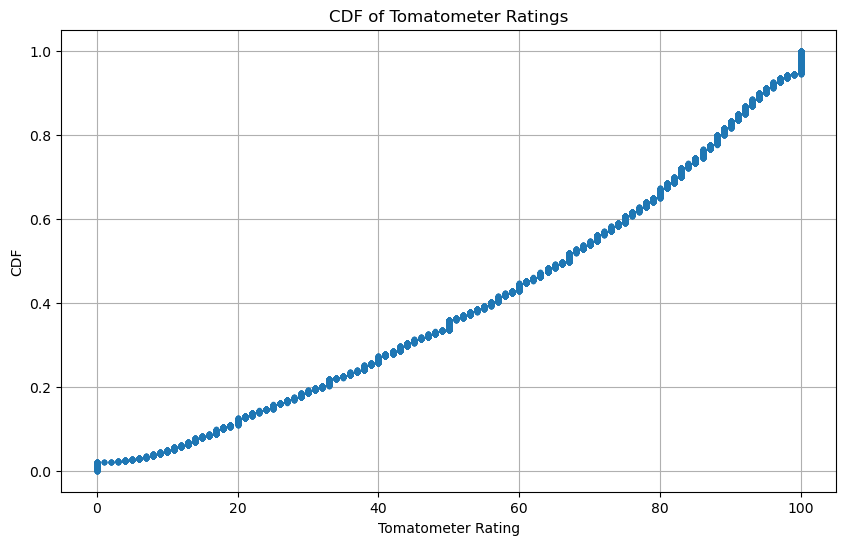

In [23]:
# Extract relevant column and remove missing values
tomatometer_ratings = rotten_tomatoes_df['tomatometer_rating'].dropna()

# Calculate the CDF
tomatometer_ratings_sorted = np.sort(tomatometer_ratings)
cdf = np.arange(1, len(tomatometer_ratings_sorted)+1) / len(tomatometer_ratings_sorted)

# Plot the CDF
plt.figure(figsize=(10, 6))
plt.plot(tomatometer_ratings_sorted, cdf, marker='.', linestyle='none')
plt.title('CDF of Tomatometer Ratings')
plt.xlabel('Tomatometer Rating')
plt.ylabel('CDF')
plt.grid(True)
plt.show()

##### Explanation:
The CDF is calculated by sorting the tomatometer_rating values and then generating an array that represents the cumulative probability of each rating.

The CDF is plotted with tomatometer_rating on the x-axis and the cumulative probability on the y-axis.

##### Interpretation:
The CDF plot allows us to see how tomatometer_rating is distributed. We can determine what percentage of movies have a critic rating below or above a particular value.

A steep slope indicates a concentration of ratings around certain values, suggesting that many movies receive similar critic ratings. A more gradual slope indicates a wider spread in critic ratings, showing greater diversity in how movies are rated.

The CDF helps answer questions about the overall distribution of critic ratings. If we're interested in understanding how harsh or lenient critics are in their ratings, the CDF provides a clear picture of the overall distribution. If the CDF indicates that most ratings are clustered in the upper range (e.g., above 70), it might suggest that critics are generally favorable towards most movies in the dataset.

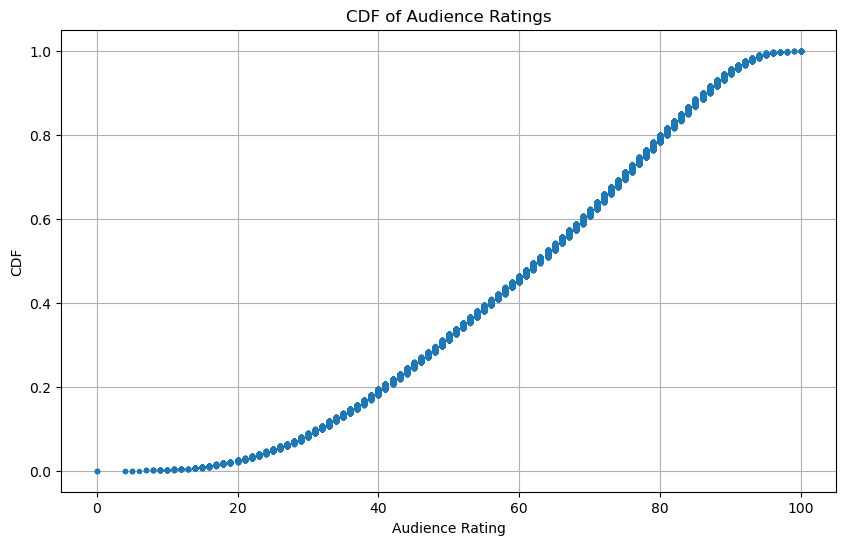

In [24]:
# Extract relevant column and remove missing values
audience_ratings = rotten_tomatoes_selected_df['audience_rating'].dropna()

# Calculate the CDF
audience_ratings_sorted = np.sort(audience_ratings)
cdf = np.arange(1, len(audience_ratings_sorted)+1) / len(audience_ratings_sorted)

# Plot the CDF
plt.figure(figsize=(10, 6))
plt.plot(audience_ratings_sorted, cdf, marker='.', linestyle='none')
plt.title('CDF of Audience Ratings')
plt.xlabel('Audience Rating')
plt.ylabel('CDF')
plt.grid(True)
plt.show()

##### Explanation:
The CDF is calculated by sorting the audience_rating values and then creating an array representing the cumulative probability of each rating.

The CDF is plotted with audience ratings on the x-axis and the cumulative probability on the y-axis.

##### Interpretation:
The CDF plot allows to understand the distribution of audience ratings. For example, if 50% of the movies have a rating below 80, the CDF will cross 0.5 (50%) at a rating of 80.

The slope of the CDF can tell about the concentration of ratings. A steep slope suggests that many movies have similar ratings, while a gradual slope indicates more variability in ratings.

If the CDF shows that a large percentage of movies have high audience ratings (e.g., above 80), this might suggest that audience ratings are generally positive, indicating a possible leniency or preference towards certain types of movies.
If the CDF is more gradual, it might suggest a more balanced spread of ratings, with a significant number of movies receiving lower ratings, which could indicate a more critical audience or a diverse range of movie quality.

## Plot 1 analytical distribution and provide your analysis on how it applies to the dataset you have chosen (Chapter 5).

For this part of the project I'll create two analytical comparisons, tomatometer_rating and audience_rating.

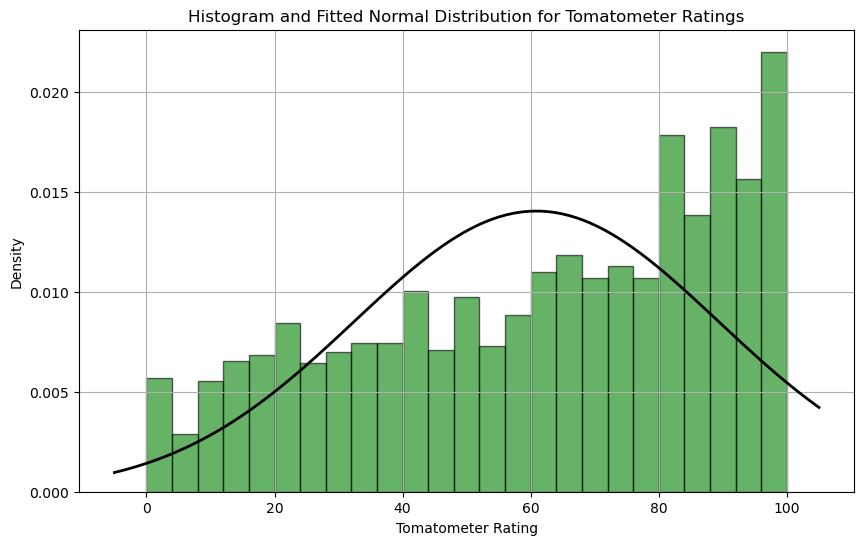

In [25]:
# Fit a normal distribution to the data
mu, std = norm.fit(tomatometer_ratings)

# Plot the histogram of the data
plt.figure(figsize=(10, 6))
plt.hist(tomatometer_ratings, bins=25, density=True, alpha=0.6, color='g', edgecolor='black')

# Plot the PDF of the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title('Histogram and Fitted Normal Distribution for Tomatometer Ratings')
plt.xlabel('Tomatometer Rating')
plt.ylabel('Density')
plt.grid(True)
plt.show()

##### Analysis of the Fit
The histogram represents the actual distribution of tomatometer ratings, while the black line represents the fitted normal distribution.
By comparing the two, we can see the histogram doesn't follows the fitted curve closely.
Deviations between the histogram and the curve indicate skewness, kurtosis, or other distribution characteristics not captured by a normal distribution.

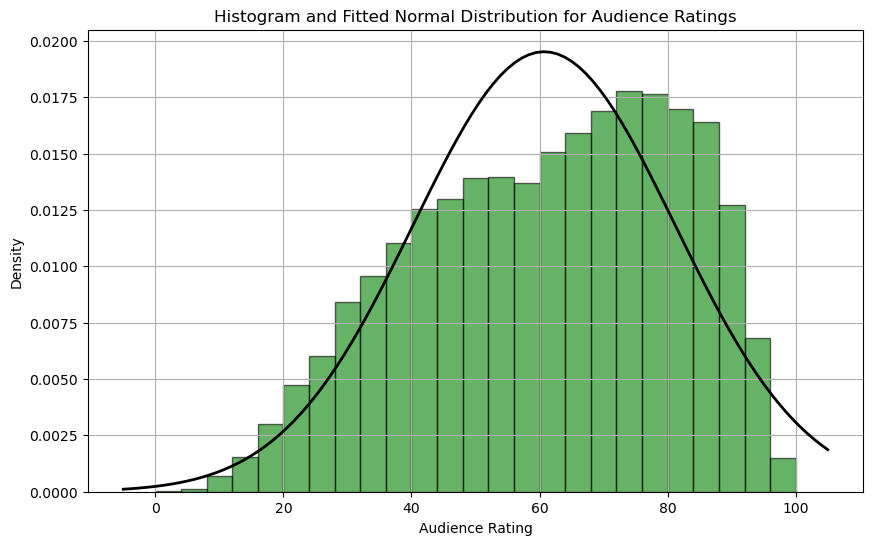

In [26]:
# Fit a normal distribution to the data
mu, std = norm.fit(audience_ratings)

# Plot the histogram of the data
plt.figure(figsize=(10, 6))
plt.hist(audience_ratings, bins=25, density=True, alpha=0.6, color='g', edgecolor='black')

# Plot the PDF of the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title('Histogram and Fitted Normal Distribution for Audience Ratings')
plt.xlabel('Audience Rating')
plt.ylabel('Density')
plt.grid(True)
plt.show()



##### Analysis of the Fit
The histogram represents the actual distribution of audience ratings, while the black line represents the fitted normal distribution.
By comparing the two, we can see how the histogram follows the fitted curve. Deviations between the histogram and the curve indicate skewness, kurtosis, or other distribution characteristics not captured by a normal distribution.

## Create two scatter plots comparing two variables and provide your analysis on correlation and causation. Remember, covariance, Pearson’s correlation, and Non-Linear Relationships should also be considered during your analysis (Chapter 7).


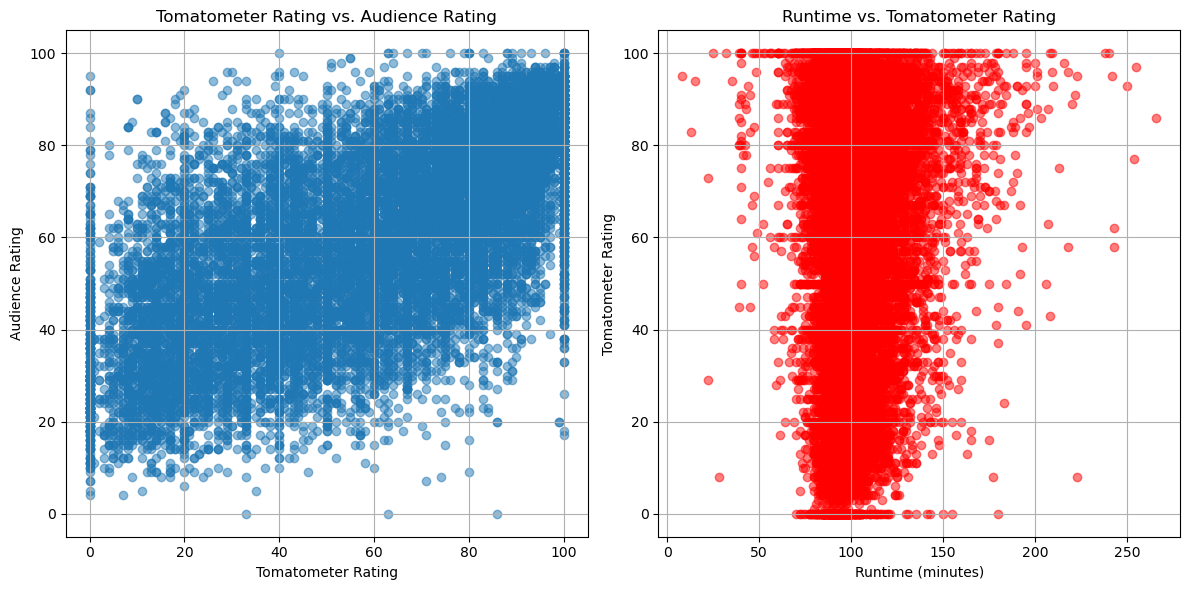

Covariance between Tomatometer Rating and Audience Rating: 383.72
Pearson's Correlation between Tomatometer Rating and Audience Rating: 0.66
Covariance between Runtime and Tomatometer Rating: 56.39
Pearson's Correlation between Runtime and Tomatometer Rating: 0.11


In [27]:
# Scatter Plot 1: Tomatometer Rating vs. Audience Rating
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(rotten_tomatoes_selected_df['tomatometer_rating'], rotten_tomatoes_selected_df['audience_rating'], alpha=0.5)
plt.title('Tomatometer Rating vs. Audience Rating')
plt.xlabel('Tomatometer Rating')
plt.ylabel('Audience Rating')
plt.grid(True)

# Scatter Plot 2: Runtime vs. Tomatometer Rating
plt.subplot(1, 2, 2)
plt.scatter(rotten_tomatoes_selected_df['runtime'], rotten_tomatoes_selected_df['tomatometer_rating'], alpha=0.5, color='r')
plt.title('Runtime vs. Tomatometer Rating')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Tomatometer Rating')
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate Covariance and Pearson's Correlation
cov_tomatometer_audience = np.cov(rotten_tomatoes_selected_df['tomatometer_rating'], rotten_tomatoes_selected_df['audience_rating'])[0, 1]
corr_tomatometer_audience, _ = pearsonr(rotten_tomatoes_selected_df['tomatometer_rating'], rotten_tomatoes_selected_df['audience_rating'])

cov_runtime_tomatometer = np.cov(rotten_tomatoes_selected_df['runtime'], rotten_tomatoes_selected_df['tomatometer_rating'])[0, 1]
corr_runtime_tomatometer, _ = pearsonr(rotten_tomatoes_selected_df['runtime'], rotten_tomatoes_selected_df['tomatometer_rating'])

print(f"Covariance between Tomatometer Rating and Audience Rating: {cov_tomatometer_audience:.2f}")
print(f"Pearson's Correlation between Tomatometer Rating and Audience Rating: {corr_tomatometer_audience:.2f}")

print(f"Covariance between Runtime and Tomatometer Rating: {cov_runtime_tomatometer:.2f}")
print(f"Pearson's Correlation between Runtime and Tomatometer Rating: {corr_runtime_tomatometer:.2f}")

##### Analysis of Correlation and Causation
1. Tomatometer Rating vs. Audience Rating
    - The scatter plot shows a positive relationship between tomatometer ratings and audience ratings, indicating that higher critic ratings tend to coincide with higher audience ratings.
    - The covariance of 383.72 and Pearson’s correlation coefficient of 0.66 confirm a moderate to strong positive linear correlation.
    - However, correlation does not imply causation; this positive relationship does not necessarily mean that one causes the other. There could be underlying factors, such as genre, marketing, or the movie's quality, influencing both ratings.
2. Runtime vs. Tomatometer Rating
    - The scatter plot shows a weaker relationship between runtime and tomatometer rating. The points appear more spread out, suggesting a lower correlation.
    - The covariance of 56.39 and Pearson’s correlation coefficient of 0.11 suggest a weak or negligible linear relationship.
    - The low correlation indicates that runtime alone does not significantly influence tomatometer ratings. However, there could be non-linear relationships or other confounding variables that affect both runtime and ratings.

Consideration of Non-Linear Relationships
    - Both scatter plots focus on linear relationships, as indicated by Pearson’s correlation.
    - If the data shows curves or clusters, non-linear methods such as polynomial regression might be needed to capture more complex relationships.
    - For example, it’s possible that very short or very long movies could have different effects on ratings, which wouldn’t be captured by a linear correlation.

## Conduct a test on your hypothesis using one of the methods covered in Chapter 9.

In [28]:
# Calculate the means
mean_tomatometer = rotten_tomatoes_selected_df['tomatometer_rating'].mean()
mean_audience = rotten_tomatoes_selected_df['audience_rating'].mean()

print(f"Mean Tomatometer Rating: {mean_tomatometer:.2}")
print(f"Mean Audience Rating: {mean_audience:.2}")

# Perform a two-sample t-test
t_stat, p_value = ttest_ind(rotten_tomatoes_selected_df['tomatometer_rating'], rotten_tomatoes_selected_df['audience_rating'])

print(f"T-statistic: {t_stat:.2}")
print(f"P-value: {p_value:.2}")

# Interpretation of the Results
alpha = 0.05  # significance level

if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the average Tomatometer and Audience ratings.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the average Tomatometer and Audience ratings.")

Mean Tomatometer Rating: 6e+01
Mean Audience Rating: 6.1e+01
T-statistic: -1.2
P-value: 0.24
Fail to reject the null hypothesis: There is no significant difference between the average Tomatometer and Audience ratings.


## For this project, conduct a regression analysis on either one dependent and one explanatory variable, or multiple explanatory variables (Chapter 10 & 11).

Converting categorical data 'content_rating' into numerical format to use in regression analysis.

In [29]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

rotten_tomatoes_selected_df['content_rating_numeric'] = label_encoder.fit_transform(
    rotten_tomatoes_selected_df['content_rating']
)

# Explanatory variables
X_multiple_numeric = rotten_tomatoes_selected_df[['audience_rating', 'runtime', 'content_rating_numeric']]

# Add a constant to the model (intercept)
X_multiple_numeric = sm.add_constant(X_multiple_numeric)

# Fit the model
model_multiple_numeric = sm.OLS(rotten_tomatoes_selected_df['tomatometer_rating'], X_multiple_numeric).fit()

# Print the summary of the multiple linear regression model with numeric content_rating
print("\nMultiple Linear Regression with Numeric Content Rating:")
print(model_multiple_numeric.summary())



Multiple Linear Regression with Numeric Content Rating:
                            OLS Regression Results                            
Dep. Variable:     tomatometer_rating   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     4585.
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        16:22:48   Log-Likelihood:                -72377.
No. Observations:               16237   AIC:                         1.448e+05
Df Residuals:                   16233   BIC:                         1.448e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

'tomatometer_rating' is the dependent variable I'm trying to predict. 

Prob (F-statistic): 0.00. The p-value associated with the F-statistic is very small, suggesting that the model is statistically significant and at least one predictor variable has a significant relationship with the dependent variable. 

audience_rating: 0.8958. This coefficient suggests that for each unit increase in audience_rating, the tomatometer_rating increases by approximately 0.896, holding all other variables constant. 

t and P>|t|: These columns show the t-statistic and p-value for each coefficient. A p-value of 0.000 indicates that the predictor is statistically significant (generally, a p-value less than 0.05 is considered significant). All predictors here have p-values of 0.000, meaning they are statistically significant. 

Model explains a significant portion of the variance in tomatometer_rating, and all predictors appear to be statistically significant. The diagnostics indicate that the model might have some issues with normality and multicollinearity, so further checking and potentially adjusting the model could be beneficial. 

# Statistical/Hypothetical Question Summary

## Outcome of the Exploratory Data Analysis (EDA): 
When I looked at the data, I found that the audience rating (what viewers think), runtime (how long the movie is), and content rating (like PG-13 or R) are important factors in predicting the tomatometer rating (a score that shows how good a movie is according to critics). I used a math method called multiple linear regression to see how these factors are related to the tomatometer rating. The results were strong, meaning these factors do matter. Still, there were some problems with the model, like the data not being perfectly normal and some predictors being too similar, which might make the model less reliable. 

## What Was Missed During the Analysis: 
I might have missed that the relationship between these factors and the tomatometer rating isn’t just a straight line (not just linear). Also, I didn’t look at how different factors might work together to influence the rating, which could have shown more complex relationships. 

## Additional Variables That Could Have Helped: 
I could have included more factors, like the movie’s genre (some movies were classified in more than one genre, making it difficult for me to create a helpful analysis), how much it cost to make, or how much money it made at the box office. These could help explain the ratings better and make our model stronger. 

## Assumptions That May Have Been Incorrect: 
I assumed that the relationships between the factors and the tomatometer rating were linear and that the factors didn’t affect each other. However, since I noticed some issues, like predictors being similar (multicollinearity), these assumptions might not be entirely correct. Also, I assumed that the model’s errors were consistent (homoscedasticity) and that the data fit a normal distribution, but this might not be true. 

## Challenges Faced and Unclear Aspects: 
One big challenge was dealing with multicollinearity, where some predictors were too similar, making it hard to understand their individual impact. It was also tricky to figure out if the model needed adjustments, like changing variables or adding interactions between them. Selecting the best model and understanding the diagnostics were likely challenging parts of the analysis. 

  

This summary covers the main points and should help you understand what was done in the analysis. 

# Note.

I created two analyses for this project’s PMF, CDF, and analytical distribution parts (tatometer_rating and audience_rating). Initially, for this class, I thought I would be able to compare how and why each movie was rated differently (sometimes, audience rating is higher than critic rating – that’s how I decide if I want to watch a movie.) But this is something that I’ll work on later with the tools I have learned so far in this curriculum. 

Thank you.  